# 01 · Understand the prediction problem

**NFL Player Trajectory Lab** · Real 2023 tracking data · Training-only exploration

Predict each selected player's x/y position for every requested frame after the throw.
The competition supplies the ball landing point, target receiver, and forecast horizon.
This notebook reads the reproducible artifacts produced by `nfl benchmark`; it does
not silently retrain a model. Notebook 00 is optional orientation.

[Source and run instructions](https://github.com/alvaromendizabal/nfl-player-trajectory)

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
LOCAL = ROOT / "artifacts" / "benchmark"
PUBLISHED = ROOT / "docs" / "results"
RESULTS = LOCAL if (LOCAL / "summary.json").exists() else PUBLISHED
READY = (RESULTS / "summary.json").exists()
if READY:
    summary = json.loads((RESULTS / "summary.json").read_text())
    eda = json.loads((RESULTS / "eda.json").read_text())
    protocol = json.loads((RESULTS / "protocol.json").read_text())
    display(
        Markdown(
            "**Report source:** "
            + (
                "local benchmark artifacts"
                if RESULTS == LOCAL
                else "published reproducible experiment snapshot"
            )
        )
    )
else:
    display(Markdown("No real-data benchmark is available. Run `nfl benchmark` after the audit."))

**Report source:** published reproducible experiment snapshot

## Freeze time before fitting

Keep all frames, players and plays of a game in one partition. These dates are checked against game identifiers and locked before training. Holdout labels are excluded from the development pipeline.

In [2]:
if READY:
    display(
        pd.DataFrame.from_dict(protocol["partitions"], orient="index").loc[
            ["train", "validation", "holdout"]
        ]
    )
    display(Markdown("**Holdout evaluation:** " + summary["holdout_evaluation"]))

,games,first_date,last_date
train,192,2023-09-07,2023-12-03
validation,32,2023-12-04,2023-12-18
holdout,48,2023-12-21,2024-01-07


**Holdout evaluation:** not_run

## Data coverage

Input rows describe observed motion; target rows are the positions we score. A trajectory is one player within one play, and can contain several target frames.

In [3]:
if READY:
    display(
        pd.DataFrame(
            {
                "Training measure": [
                    "Games",
                    "Plays",
                    "Scored trajectories",
                    "Observed rows",
                    "Target rows",
                ],
                "Count": [
                    eda[key]
                    for key in ["games", "plays", "trajectories", "input_rows", "target_rows"]
                ],
            }
        )
    )
    display(
        pd.DataFrame(eda["weeks"])[
            ["file", "games", "plays", "trajectories", "input_rows", "target_rows"]
        ]
    )

,Training measure,Count
0,Games,192
1,Plays,10007
2,Scored trajectories,32681
3,Observed rows,3450568
4,Target rows,395813


,file,games,plays,trajectories,input_rows,target_rows
0,input_2023_w01.csv,16,819,2679,285714,32088
1,input_2023_w02.csv,16,850,2758,288586,32180
2,input_2023_w03.csv,16,904,2959,297757,36080
3,input_2023_w04.csv,16,779,2517,272475,30147
4,input_2023_w05.csv,14,742,2449,254779,29319
5,input_2023_w06.csv,15,793,2608,270676,31162
6,input_2023_w07.csv,13,693,2292,233597,27443
7,input_2023_w08.csv,16,827,2705,281011,33017
8,input_2023_w09.csv,14,711,2281,252796,28291
9,input_2023_w10.csv,14,721,2365,260372,29008


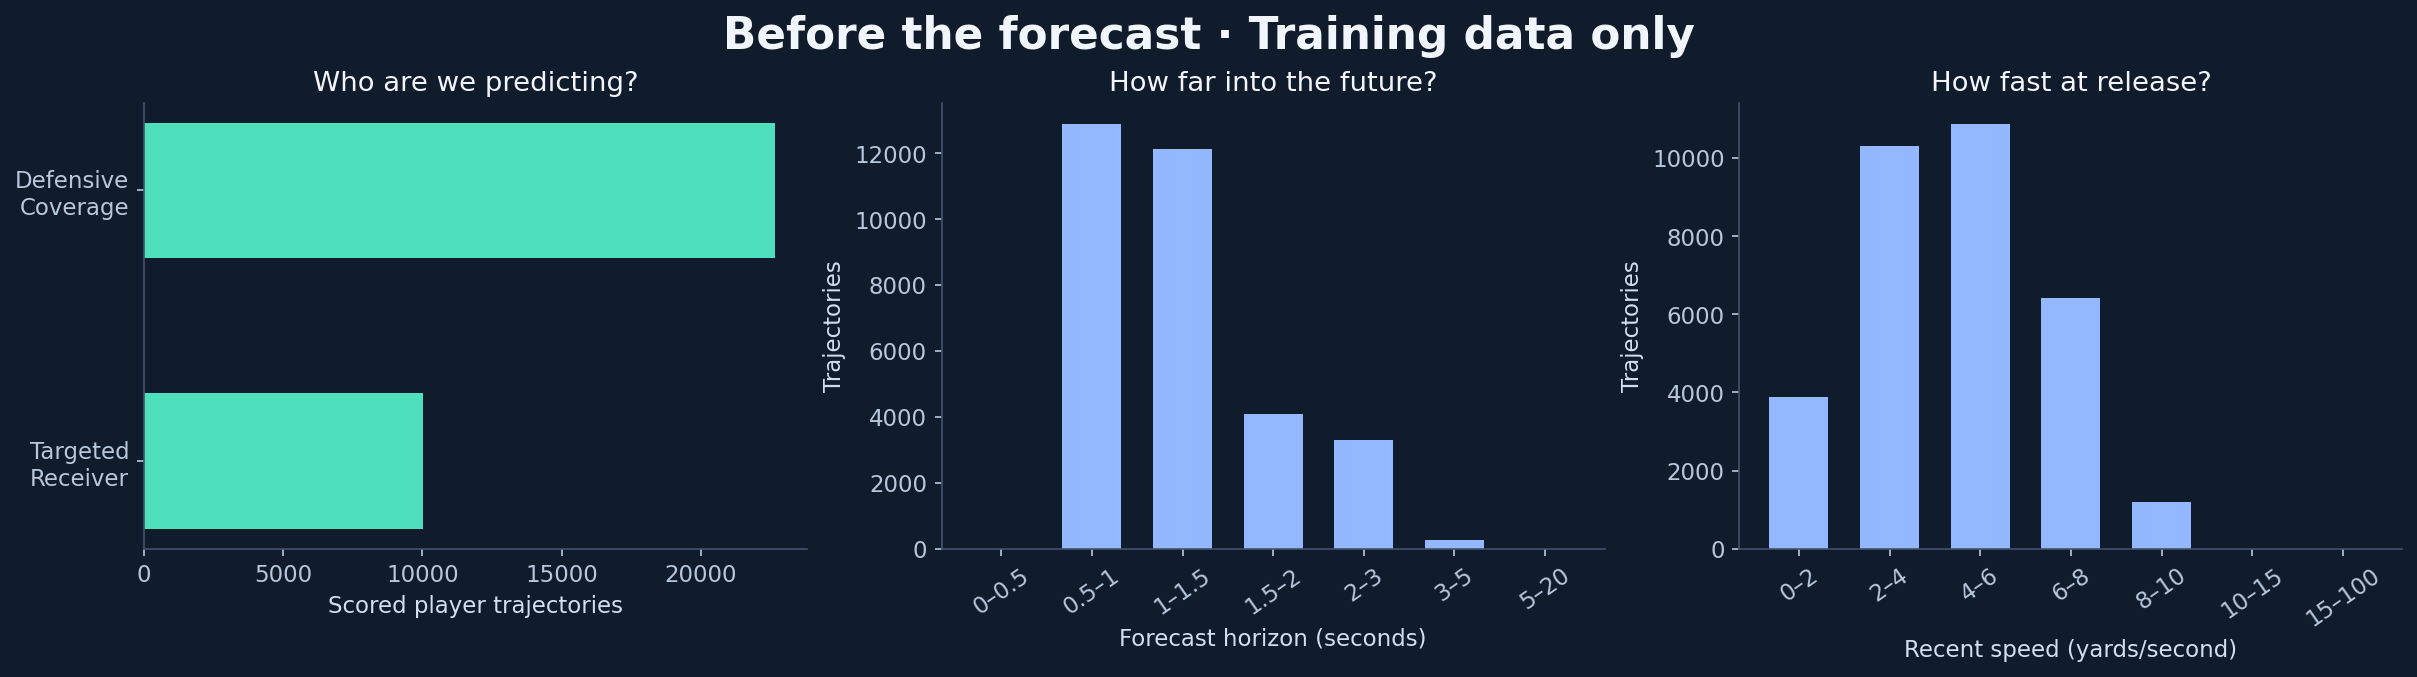

In [4]:
if READY:
    display(Image(filename=str(RESULTS / "eda.png")))

## Candidate features, not unverified importance claims

The implemented bank has **2,843 deterministic candidate features**. It uses observed
history, landing-relative motion, nearest teammates/opponents, receiver and passer
anchors, and forecast-time interactions. Missing-history and missing-neighbour masks
are explicit. Names, birth dates, player IDs as numerical predictors, future coordinates,
and post-play outcomes are excluded.

`nfl features` screens candidates on **training residuals only**, drops constant and
near-duplicate training features, and retains at most **64 features per challenger**.
The motion-only, landing-aware, and interaction-aware ablations share a fixed ridge
regularization and feature budget. Validation chooses a development candidate; the
48-game holdout remains reserved. A large candidate count is not evidence of accuracy.

In [5]:
from nfl_trajectory.features import feature_catalog

catalog = feature_catalog()
display(Markdown(f"**Candidate feature count:** {len(catalog):,}"))
display(catalog.groupby("family").size().rename("Candidate features").to_frame())

**Candidate feature count:** 2,843

,Candidate features
family,
availability,31
context,12
forecast,6
forecast_interactions,462
history_lags,560
history_summaries,1568
interactions,204


## Which relationships deserve a model experiment?

Motion measured relative to the supplied landing point expresses a football-specific hypothesis: closing speed, lateral motion, and time remaining describe different paths even when instantaneous speed is equal. Receiver and defender geometry adds context, but its value must be measured rather than inferred from feature count.

The chart below ranks **training-residual association**, used for screening only. It is not causal importance and is not a validation score. Correlated candidates can substitute for one another under the 64-feature budget. The next notebook tests motion-only, landing-aware, and interaction-aware feature sets on identical later games.

**Evidence:** published experiment snapshot

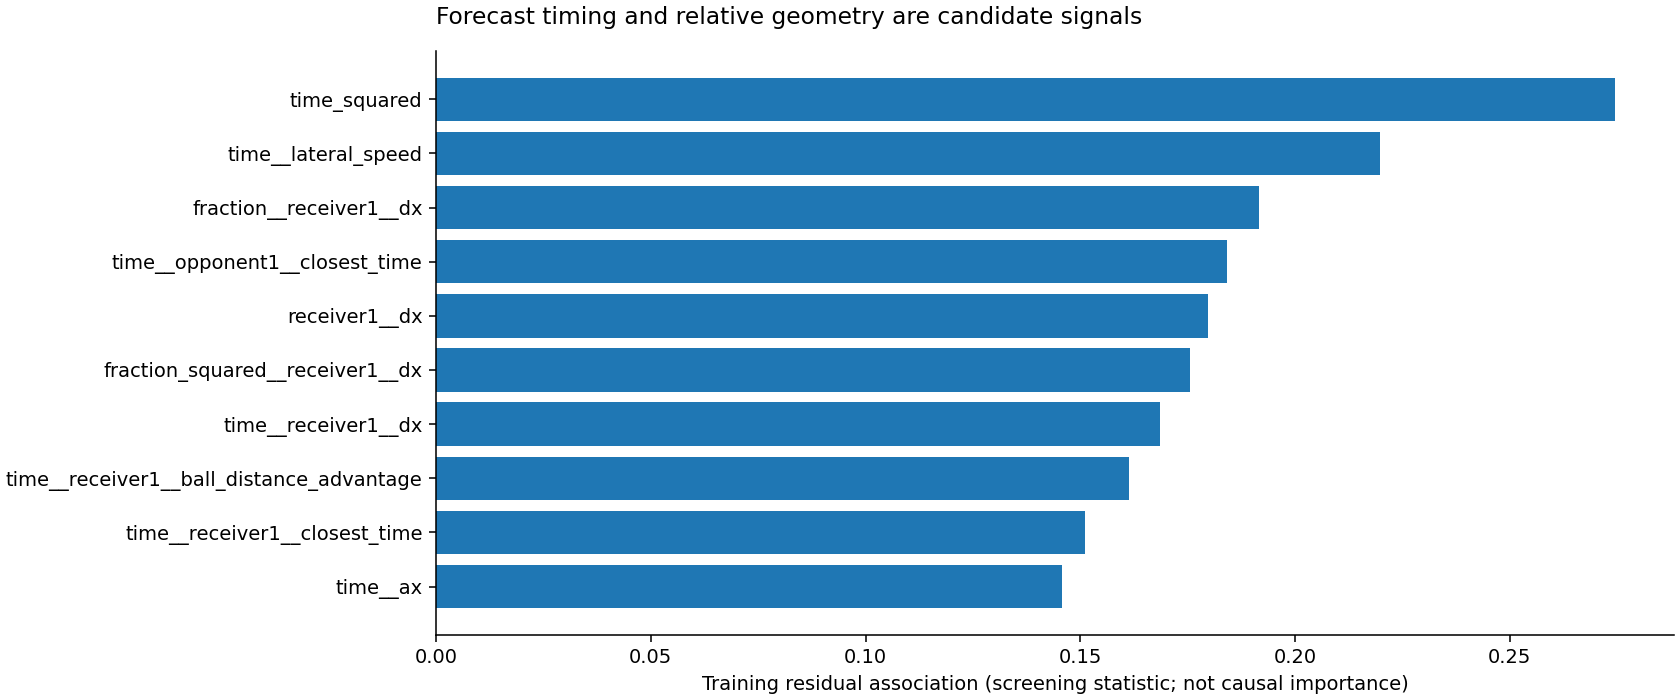

,feature,signal,training_residual_correlation
0,time_squared,motion,0.2746
1,time__lateral_speed,landing,0.2199
2,fraction__receiver1__dx,interaction,0.1917
3,time__opponent1__closest_time,interaction,0.1841
4,receiver1__dx,interaction,0.1797
5,fraction_squared__receiver1__dx,interaction,0.1755
6,time__receiver1__dx,interaction,0.1687
7,time__receiver1__ball_distance_advantage,interaction,0.1613
8,time__receiver1__closest_time,interaction,0.1511
9,time__ax,motion,0.1457


In [6]:
import io

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

feature_local = ROOT / "artifacts/features/summary.json"
feature_public = PUBLISHED / "feature_summary.json"
feature_path = feature_local if feature_local.is_file() else feature_public
if feature_path.is_file():
    research = json.loads(feature_path.read_text())
    assert research["screening_split"] == "train"
    assert research["candidate_features"] == len(catalog)
    assert research["holdout_evaluation"] == "not_run"
    associations = pd.DataFrame(research["top_training_associations"])
    display(
        Markdown(
            "**Evidence:** "
            + (
                "local experiment"
                if feature_path == feature_local
                else "published experiment snapshot"
            )
        )
    )
    top = associations.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")
    ax.barh(top["feature"], top["training_residual_correlation"])
    ax.set_xlabel("Training residual association (screening statistic; not causal importance)")
    ax.set_title("Forecast timing and relative geometry are candidate signals", loc="left", pad=14)
    ax.spines[["top", "right"]].set_visible(False)
    image = io.BytesIO()
    fig.savefig(image, format="png", dpi=140)
    plt.close(fig)
    display(Image(data=image.getvalue()))
    display(associations.head(10)[["feature", "signal", "training_residual_correlation"]].round(4))
else:
    display(
        Markdown("No feature experiment result is available; no importance values are invented.")
    )